In [1]:
%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.constants as const

from astropy.table import Table
from regions import Regions

plots_dir = "/Users/bene/Desktop/mpe/plots/"

In [2]:
from functions import read_catalog

cat = Table.read("../fits/catalogs/mawatari_matched.fits")
matched_mask = cat["matched_in_reference"] == False
missed = cat[matched_mask]

#cat_ = Table.read("../fits/catalogs/combined_manual_vdfi_matched.fits")
#matched_mask_ = cat_["matched_in_reference"] == True
matched = cat[~matched_mask]

  Wende 1 Filter an:
  Filter cube_value == 0                    → 5 / 79
  → 5 Objekte nach Filterung.
Lade Cube: /Volumes/EXTERN/MPE/fits/cube/cube.fits
  Shape: (1036, 2478, 2260)
  Erzeuge 5 Cutouts ...


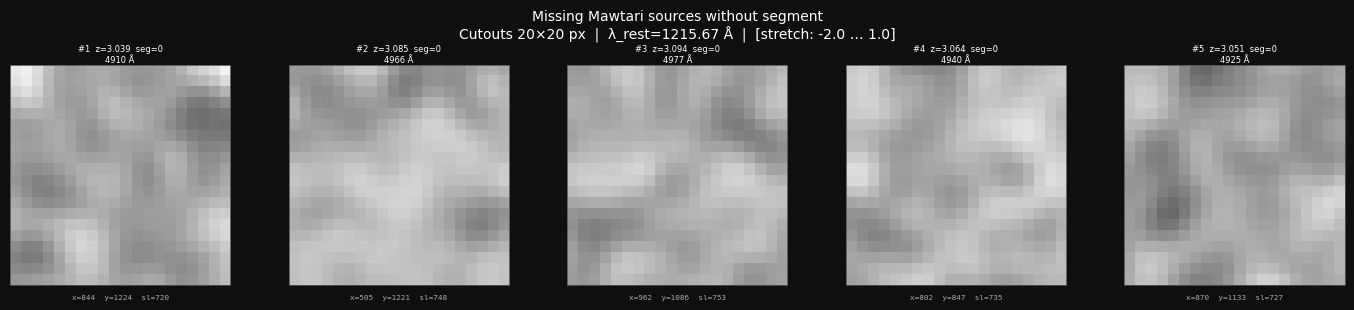

  Gespeichert: ../plots/missing_mawatari_sources_noseg.pdf


In [3]:
from functions import plot_cutout_grid

cube = "/Volumes/EXTERN/MPE/fits/cube/cube.fits"
segment = "/Volumes/EXTERN/MPE/fits/segmentierung/combined_cube.fits"

plot_cutout_grid(
    missed,
    cube,
    "../plots/missing_mawatari_sources_noseg.pdf",
    col_seg         = "cube_value",
    filters         = [{"column": "cube_value", "op": "==", "value": 0}],
    use_fixed_stretch = True,
    vmin_fixed      = -2.0,
    vmax_fixed      =  1.0,
    cmap            = "grey",
    title           = "Missing Mawtari sources without segment"
)

In [4]:
! pwd

/Users/bene/Desktop/mpe/notebooks_neu


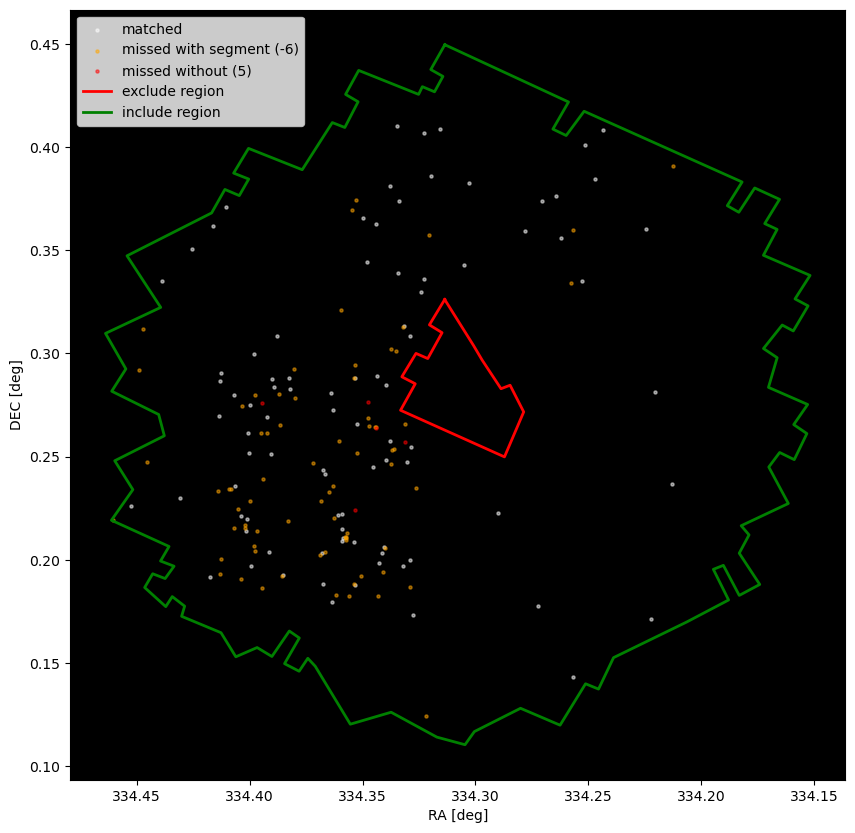

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

regions = Regions.read("/Users/bene/Desktop/mpe/regions/fov.reg", format="ds9")

# Alle Quellen
ax.scatter(matched["vdfi_ra_vdfi"], matched["vdfi_dec_vdfi"], s=5, c="white", alpha=0.5,
           label="matched")

mask = missed["cube_value"] == 0

ax.scatter(missed["RA"][~mask], missed["DEC"][~mask], s=5, c="orange",
           alpha=0.5, label=f"missed with segment ({~mask.sum()})")
ax.scatter(missed["RA"][mask], missed["DEC"][mask], s=5, c="red", alpha=0.5,
           label=f"missed without ({mask.sum()})")

# Regionen in WCS (RA/DEC) einzeichnen
r0_sky = regions[0]
r1_sky = regions[1]

vra0, vdec0 = r0_sky.vertices.ra.deg, r0_sky.vertices.dec.deg
vra1, vdec1 = r1_sky.vertices.ra.deg, r1_sky.vertices.dec.deg

ax.plot(np.append(vra0, vra0[0]), np.append(vdec0, vdec0[0]), c="red", lw=2,
        label="exclude region")
ax.plot(np.append(vra1, vra1[0]), np.append(vdec1, vdec1[0]), c="green", lw=2,
        label="include region")

ax.invert_xaxis()

ax.set_xlabel("RA [deg]")
ax.set_ylabel("DEC [deg]")
ax.set_facecolor("black")
ax.legend()
plt.savefig(os.path.join(plots_dir, "Mawatari_map.pdf"))
plt.show()

### Analysis plots of the mawatari sources

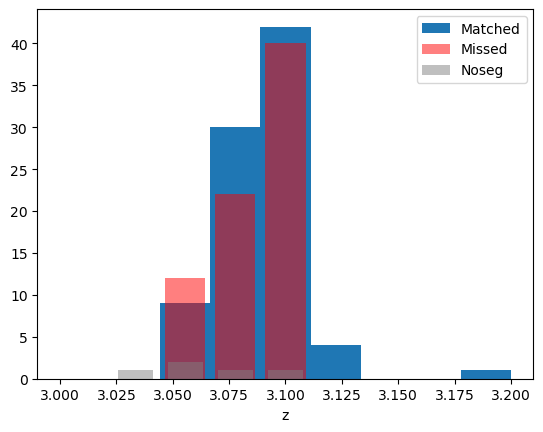

In [ ]:
bins = np.linspace(3., 3.2, 10)

plt.hist(matched["vdfi_z_vdfi"], bins=bins, label="Matched")
plt.hist(missed["z"][~mask], bins=bins, color="red", alpha=0.5, label="Missed",
         rwidth=0.8)
plt.hist(missed["z"][mask], bins=bins, color="grey", alpha=0.5,
         label="Noseg", rwidth=0.7)

plt.xlabel("z")
plt.legend()
plt.savefig("/Users/bene/Desktop/mpe/plots/Mawatari_Hist.pdf")
plt.show()

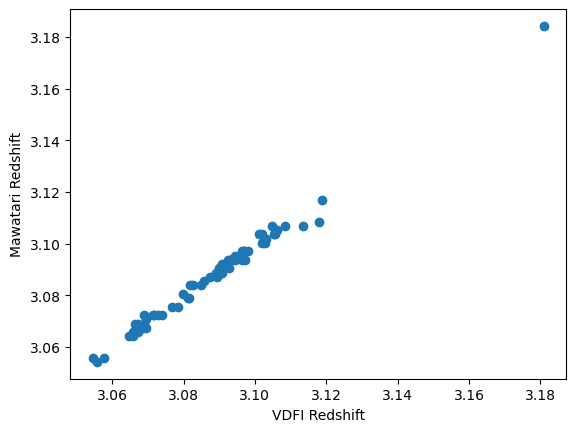

In [ ]:
auto_z = matched["vdfi_z_vdfi"]
mawa_z = matched["z_manual"]
plt.scatter(auto_z, mawa_z)
plt.xlabel("VDFI Redshift")
plt.ylabel("Mawatari Redshift")
plt.savefig("../plots/z_match.pdf")
plt.show()

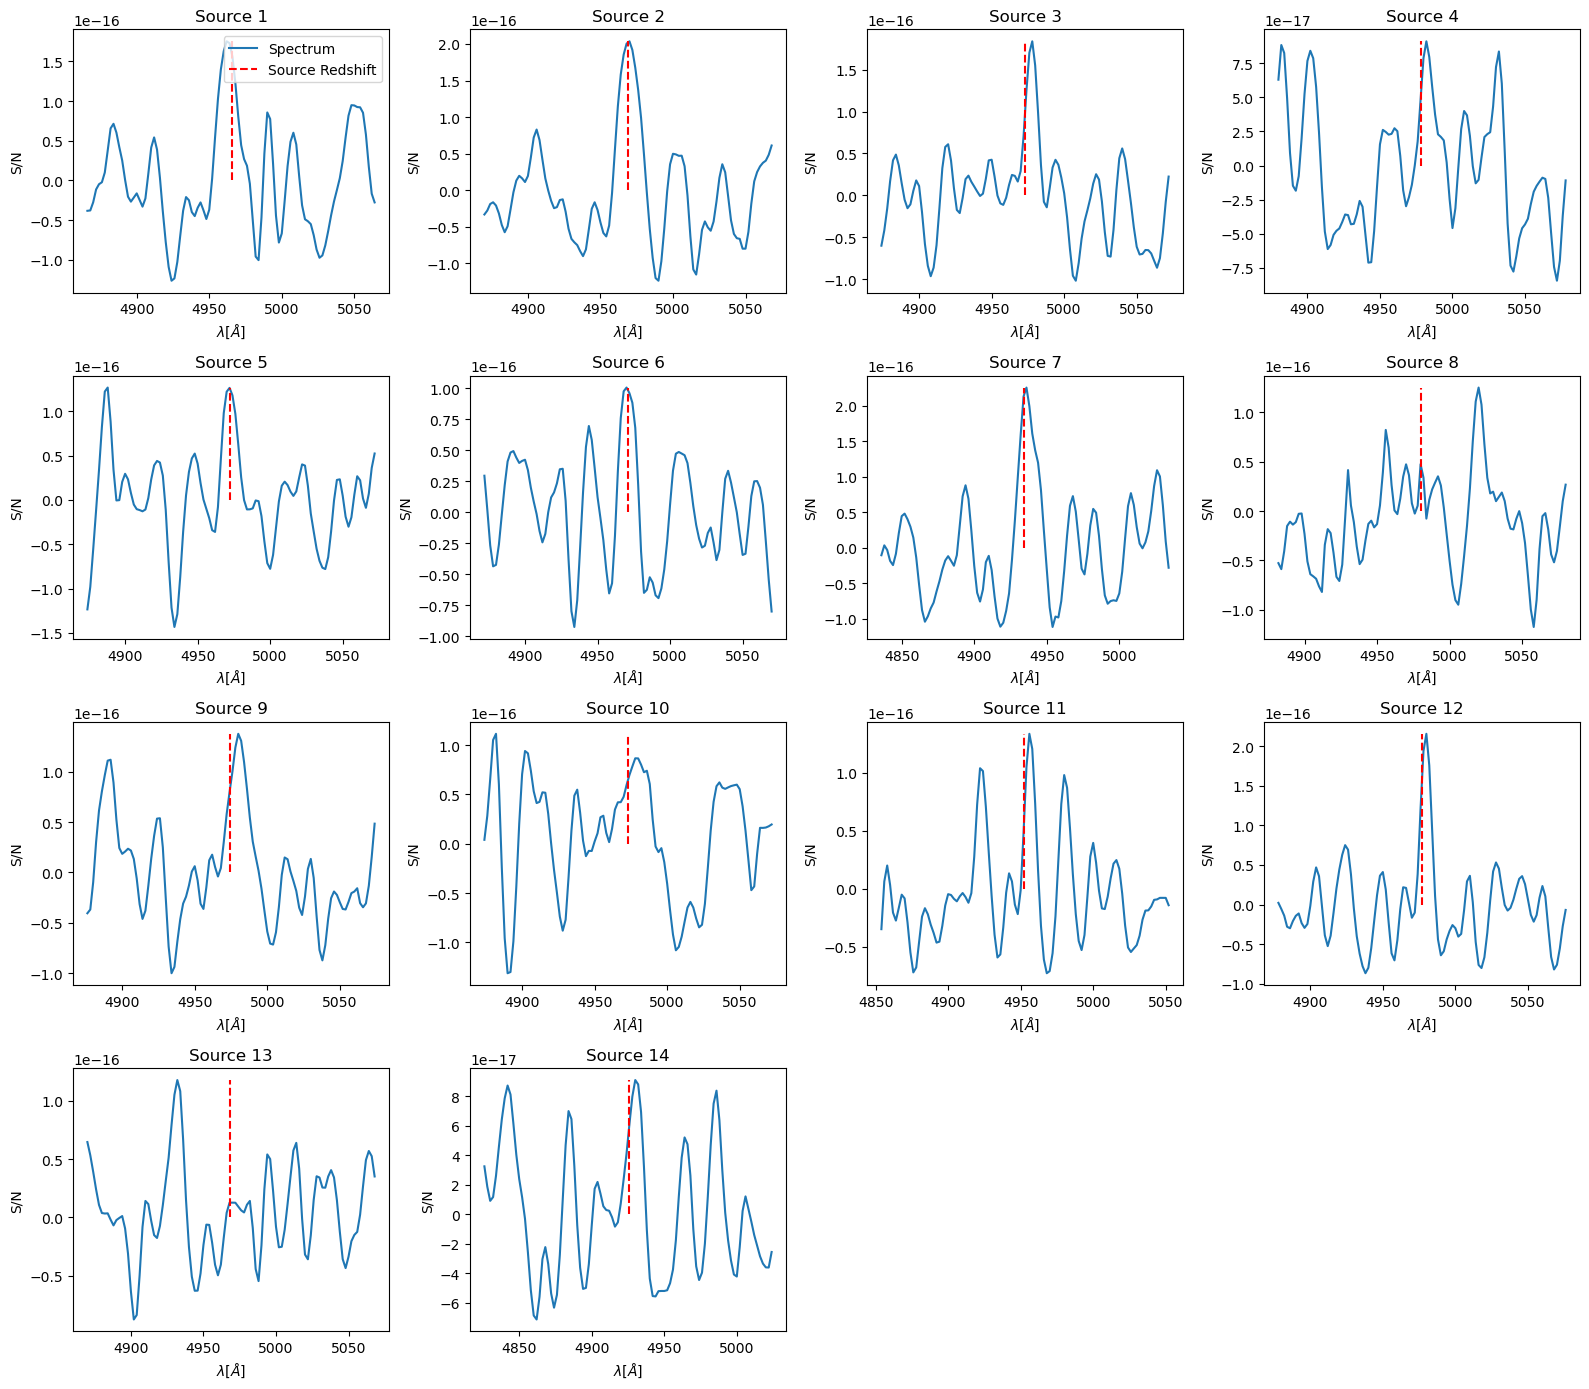

In [8]:
import math
import matplotlib.pyplot as plt
from tools.cubes import Cube

cube_path = "/Users/bene/Desktop/mpe/fits/cube.fits"
cube = Cube(cube_path)

lam = 1215.67
bound = 100
radius = 3

mask = (missed["cube_value"] > 0) & (missed["PROB"] < 0.5)
missing = missed[mask]

# ==========================================
# GEWÜNSCHTE ANZAHL AN PLOTS HIER EINSTELLEN
# ==========================================
n_plots = len(mask)  # Hier einfach jede beliebige Zahl eintragen (z.B. 10, 25, 12, ...)

# Absicherung: Wir können nicht mehr plotten, als Daten da sind
num_plots = min(n_plots, len(missing))

# Dynamische Grid-Berechnung (wählt automatisch passende Zeilen/Spalten)
# z.B. bei 25 -> 5x5, bei 10 -> 4x3, bei 12 -> 4x3 usw.
n_cols = math.ceil(math.sqrt(num_plots))
n_rows = math.ceil(num_plots / n_cols)

# Skaliere die Grafik-Größe dynamisch basierend auf der Spalten-/Zeilenanzahl
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5), sharey=False)

# Falls es nur ein einziger Plot ist, machen wir eine Liste daraus, damit flatten() nicht crasht
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Schleife über die tatsächlich berechneten Plots
for m in range(num_plots):
    ax = axes[m]
    
    x, y = cube.world2pix(missing["RA"][m], missing["DEC"][m])
    pos = lam * (missing["z"][m] + 1)
    wave, flux = cube.get_spectrum(x, y, radius)
    
    plot_mask = (wave > (pos - bound)) & (wave < (pos + bound))
    wave, flux = wave[plot_mask], flux[plot_mask]
    
    ax.plot(wave, flux, label="Spectrum")
    ax.vlines(pos, 0, max(flux) if len(flux) > 0 else 1, color="r",
              linestyle="--", label="Source Redshift")
    
    ax.set_xlabel(r"$\lambda [\AA]$")
    ax.set_ylabel(r"S/N")
    ax.set_title(f"Source {m+1}")
    if m == 0:
        ax.legend()

# Falls das mathematische Grid größer ist als unsere 'num_plots' (z.B. bei 10 Plots in einem 4x3 Grid),
# löschen wir die leeren, ungenutzten Subplots am Ende, damit sie nicht weiß im PDF auftauchen.
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../plots/spectra_of_missed_sources.pdf")
plt.show()

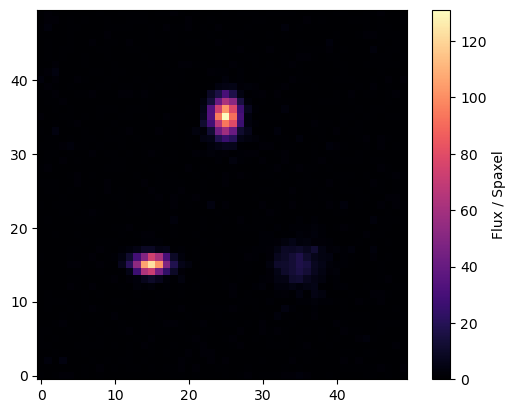

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simulated_ifu_source(shape, x0, y0, sigma_x, eccentricity, total_flux):
    y, x = np.ogrid[:shape[0], :shape[1]]
    
    sigma_y = sigma_x * eccentricity
    amplitude = total_flux / (2 * np.pi * sigma_x * sigma_y)
    
    exponent = -((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2))
    return amplitude * np.exp(exponent)

grid_size = (50, 50)
ifu_data = np.zeros(grid_size)

# Beispiel-Parameter: (x, y, sigma_x, eccentricity, flux)
# eccentricity < 1: flach in y-Richtung | > 1: gestreckt in y-Richtung
test_sources = [
    (15, 15, 1.5, 0.6, 500),  # Hell, stark exzentrisch
    (35, 15, 2.0, 1.0, 200),  # Schwächer, perfekt rund
    (25, 35, 1.2, 1.4, 800)   # Sehr hell, vertikal gestreckt
]

for x0, y0, sx, ecc, flux in test_sources:
    ifu_data += simulated_ifu_source(grid_size, x0, y0, sx, ecc, flux)

# Realistisches Rauschen hinzufügen
noise_level = 0.5
ifu_data += np.random.poisson(ifu_data + noise_level) # Poisson-Rauschen

plt.imshow(ifu_data, cmap='magma', origin='lower')
plt.colorbar(label='Flux / Spaxel')
plt.savefig("../plots/simulated_sources.pdf")
plt.show()

In [28]:
with fits.open("../fits/cube.fits") as cube:
    header = cube[0].header

header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 2260                                                  
NAXIS2  =                 2478                                                  
NAXIS3  =                 1036                                                  
CTYPE3  = 'Wave    '                                                            
CRPIX3  =                  1.0                                                  
CRVAL3  =               3470.0                                                  
CDELT3  =                  2.0                                                  
CTYPE1  = 'RA---TAN'                                                            
CRPIX1  =               1154.0                                                  
CRVAL1  =    334.30461485807

In [12]:
from astropy.table import Table

tbl = Table.read("../fits/catalogs/mawatari_ew.fits")
LAE_mask = tbl["PROB"] > 0.4
#tbl[~LAE_mask]

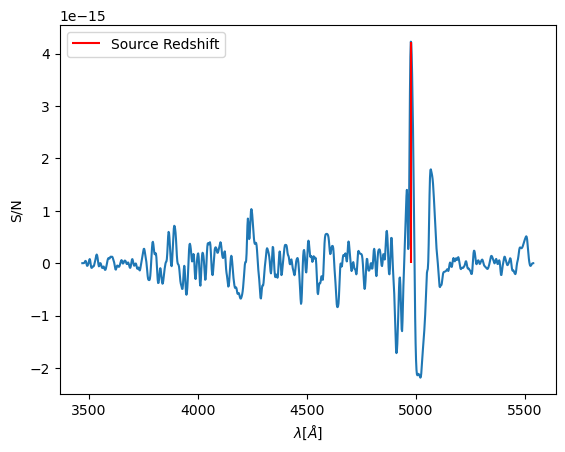

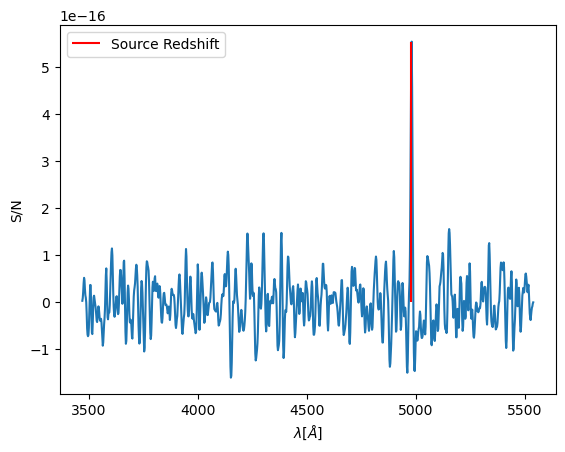

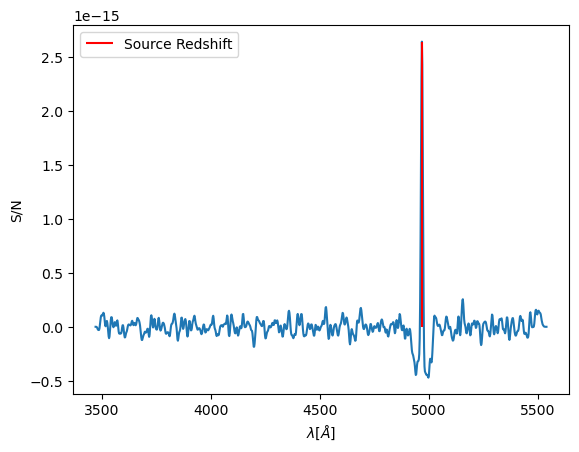

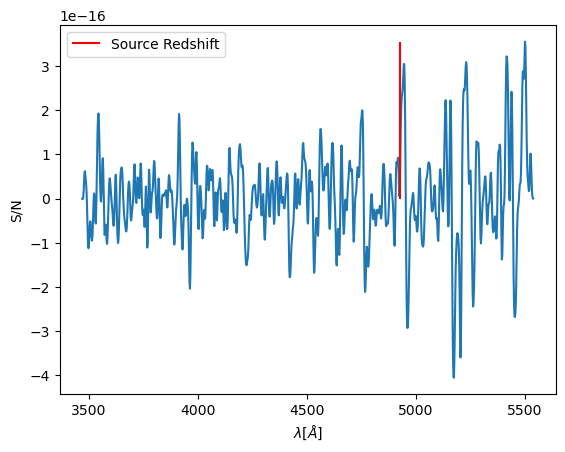

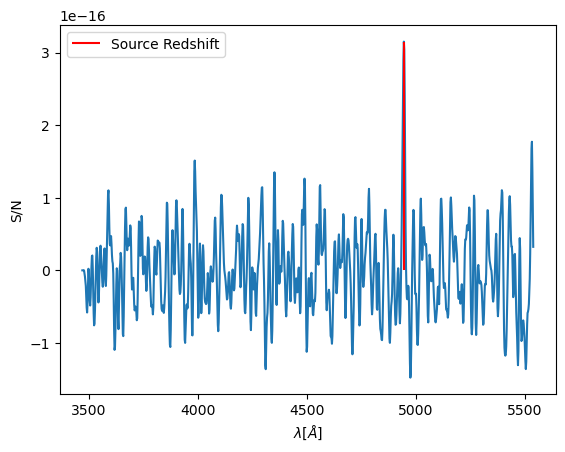

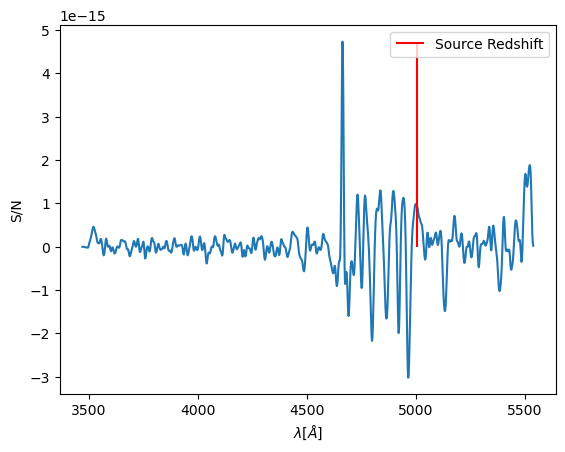

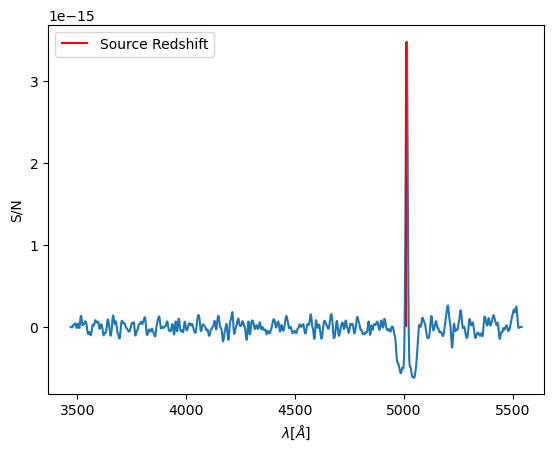

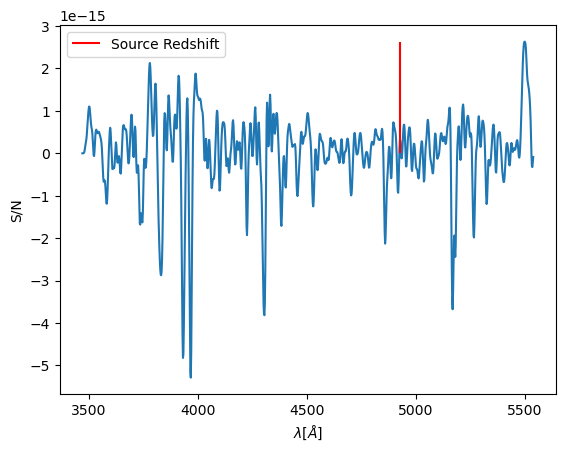

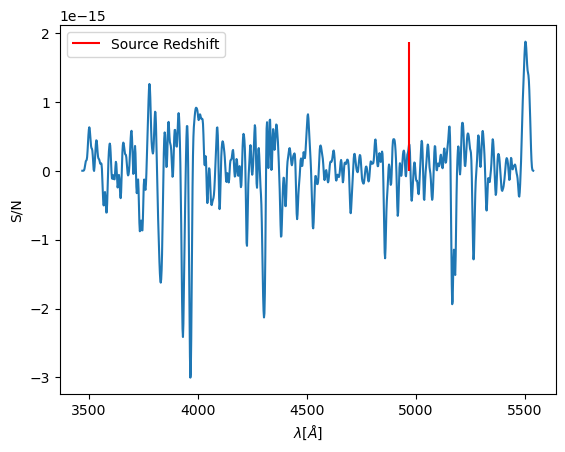

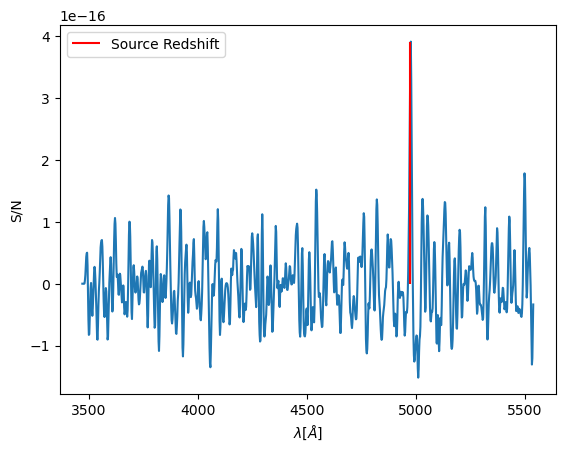

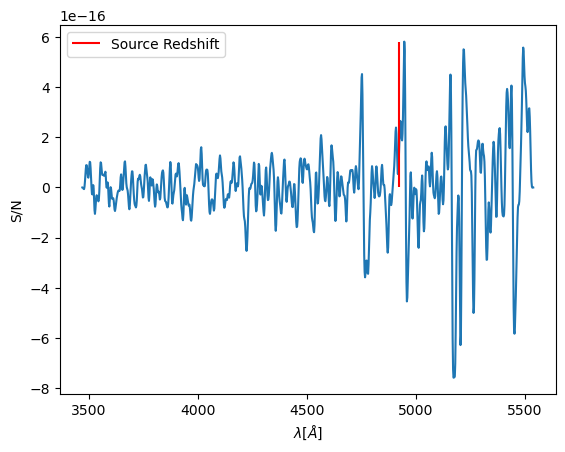

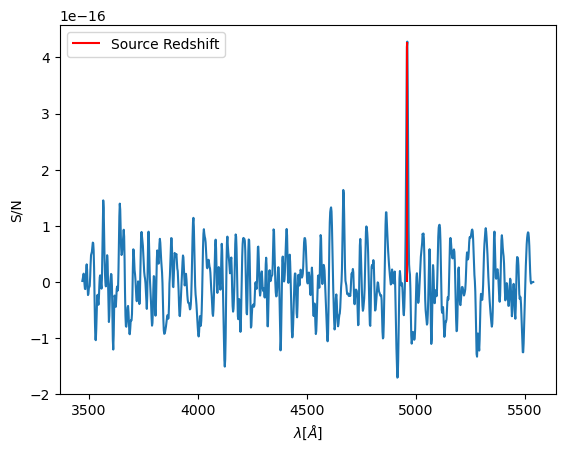

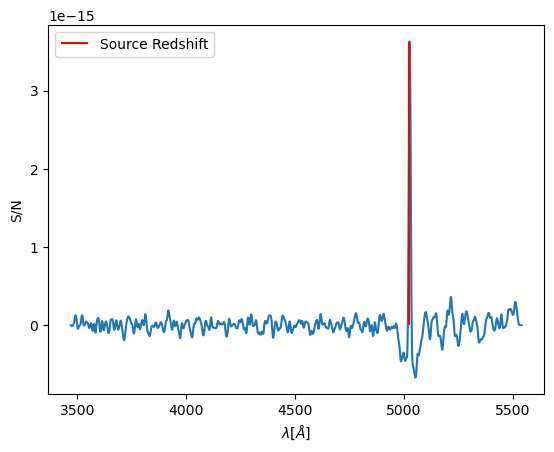

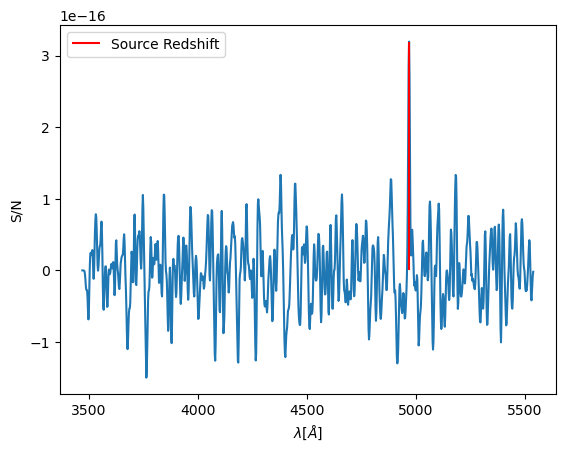

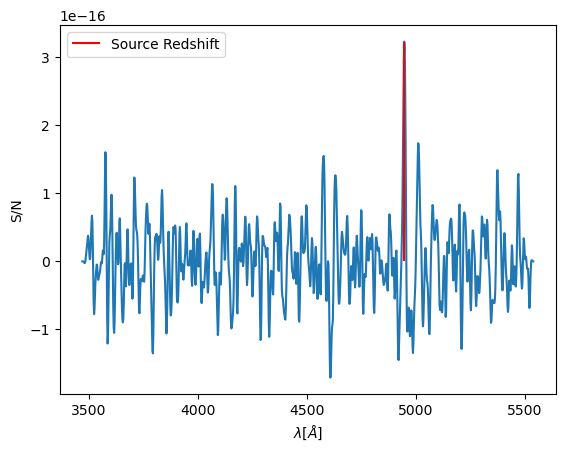

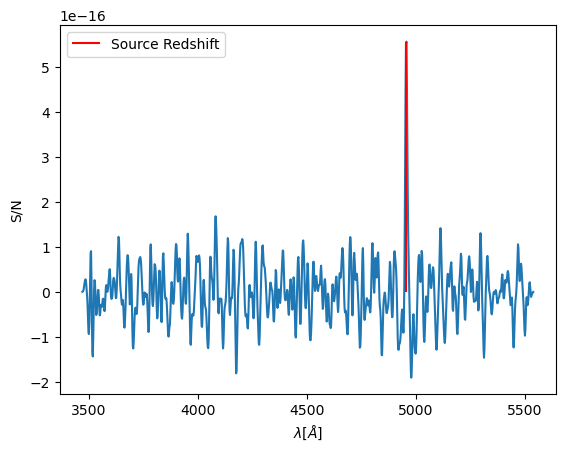

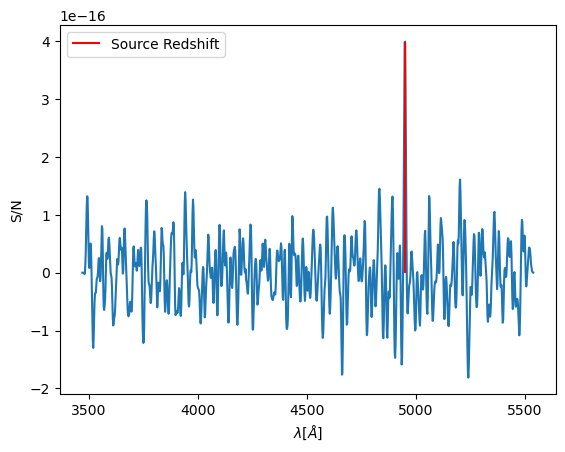

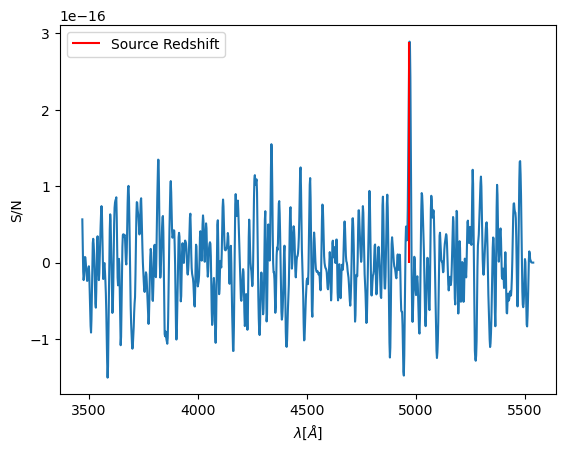

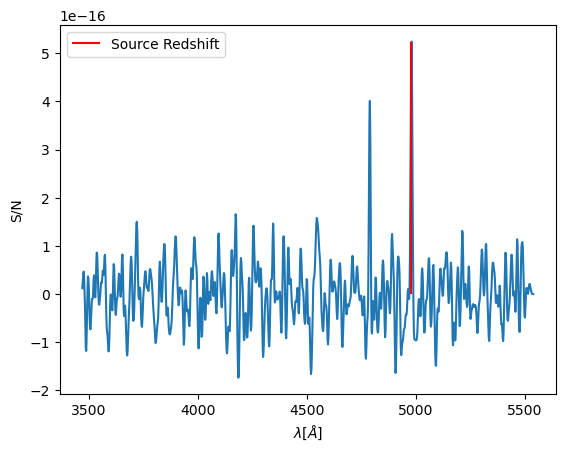

In [16]:
from tools.cubes import Cube

cube_path = "/Users/bene/Desktop/mpe/fits/cube.fits"
cube = Cube(cube_path)

lam = 1215.67
bound = 100
radius = 3

mask = ~LAE_mask
missing = tbl[mask]

for m in range(len(missing)):
    x, y = cube.world2pix(missing["RA"][m], missing["DEC"][m])
    pos = lam * (missing["REDSHIFT"][m] + 1)
    wave, flux = cube.get_spectrum(x, y, radius)
    #mask = (wave > (pos - bound)) & (wave < (pos + bound))
    #wave, flux = wave[mask], flux[mask]
    plt.plot(wave, flux)
    plt.vlines(pos, 0, max(flux), color="r", label="Source Redshift")
    plt.xlabel(r"$\lambda [\AA]$")
    plt.ylabel(r"S/N")
    plt.legend()
    plt.show()